# Respuestas de la evaluación — Proyecto CRISP-DM

**Grupo:** JARVIS_SANGRON
**Asignatura:** Minería de Datos
**Problema:** Predicción del riesgo de abandono estudiantil
**Dataset:** OULAD (Open University Learning Analytics Dataset) — `studentInfo.csv`

Este notebook responde las diez preguntas de la evaluación grupal (fases 1 a 4 de CRISP-DM).
Cada respuesta está acompañada de una celda de código que **recalcula la evidencia** desde
`../Data/studentInfo.csv`, para que los resultados sean reproducibles.

El detalle completo de cada fase está en:

- `01_entendimiento_negocio.ipynb` — negocio, calidad de datos y EDA.
- `02_regresion_logistica.ipynb` — modelo de Regresión Logística.
- `03_arbol_decision.ipynb` — modelo de Árbol de Decisión.

> Ejecutar con **Kernel → Restart Kernel and Run All Cells**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
)

RANDOM_STATE = 777
FUENTE = 'Fuente: OULAD, studentInfo.csv. Elaboración propia.'

df = pd.read_csv('../Data/studentInfo.csv')
df['abandono'] = (df['final_result'] == 'Withdrawn').astype(int)
print('Datos cargados:', df.shape)

Datos cargados: (32593, 13)


---
## Entendimiento del negocio

### Pregunta 1. ¿Qué problema concreto aborda el proyecto, qué decisión busca apoyar y cuál es su criterio de éxito?

**Problema:** casi **1 de cada 3 inscripciones** (31,16 %) termina en abandono (`Withdrawn`).
El abandono afecta a los **estudiantes**, que pierden tiempo y dinero, y a la **institución**
(coordinación académica, tutores), que pierde estudiantes y recursos.

**Decisión que apoya:** identificar **a tiempo** qué estudiantes o grupos tienen mayor riesgo
de abandono, para **priorizar el seguimiento y las tutorías** en ellos en lugar de tratar a
todos por igual.

**Conexión del análisis con la necesidad:** un modelo de clasificación estima el riesgo de
abandono de cada inscripción con la información disponible al momento de matricularse.
Con esa señal, la coordinación decide a quién contactar primero.

**Criterio de éxito de negocio:** reducir la tasa de abandono un **10 %** respecto a la línea
base, de **31,16 %** a **28,04 %**. Es una **meta futura**, todavía no un resultado.

**Criterio de éxito técnico (del modelo):** Sensibilidad (Recall) de abandono ≥ **0,75** y
F1-score ≥ **0,70** en el conjunto de prueba.

### Pregunta 2. ¿Cuál es la métrica principal y cómo se calcula?

La métrica principal es la **tasa de abandono estudiantil**. Es una **métrica de negocio**,
no una métrica de desempeño del modelo.

$$
\text{Tasa de abandono} = \frac{\text{Número de abandonos}}{\text{Número total de registros}} \times 100
$$

- **Número de abandonos:** registros con `final_result = Withdrawn`.
- **Número total de registros:** inscripciones estudiante–módulo–presentación.
- **Unidad:** porcentaje (%).

**Valor observado:** 10.156 abandonos de 32.593 registros, es decir, **31,16 %** (calculado abajo).

**Acción concreta para mejorarla:** usar el modelo para generar una lista de estudiantes con
alto riesgo al inicio del curso y asignarles **seguimiento prioritario** (tutoría, contacto
del coordinador). Luego se vuelve a medir la tasa en el siguiente periodo y se compara con
la línea base. La meta de **28,04 %** es una propuesta futura, no un resultado alcanzado.

In [2]:
total = len(df)
abandonos = df['abandono'].sum()
tasa = abandonos / total * 100
meta = tasa * (1 - 0.10)

print(f'Total de registros : {total:,}')
print(f'Abandonos          : {abandonos:,}')
print(f'No abandonos       : {total - abandonos:,}')
print(f'Tasa de abandono   : {tasa:.2f} %  (línea base)')
print(f'Meta futura (-10%) : {meta:.2f} %')

Total de registros : 32,593
Abandonos          : 10,156
No abandonos       : 22,437
Tasa de abandono   : 31.16 %  (línea base)
Meta futura (-10%) : 28.04 %


---
## Entendimiento y preparación de los datos

### Pregunta 3. ¿Cuál es la unidad de análisis, de dónde provienen los datos y cuántos registros y variables tiene?

- **Fuente:** *Open University Learning Analytics Dataset* (OULAD), datos reales anonimizados
  de la Open University (Reino Unido). Archivo `studentInfo.csv`.
- **Unidad de análisis:** cada fila es **una inscripción de un estudiante en un módulo
  (`code_module`) durante una presentación (`code_presentation`)**. Un mismo estudiante puede
  aparecer varias veces si cursó más de un módulo o repitió.
- **Dimensiones:** **32.593 registros** y **12 variables**.
- **Filtros:** **no se aplicaron filtros**; se trabajó con los 32.593 registros.

In [3]:
print('Registros :', df.shape[0])
print('Variables :', df.shape[1] - 1, '(originales, sin contar abandono)')
print('Estudiantes únicos:', df['id_student'].nunique())
print()
print(df.drop(columns='abandono').columns.tolist())

Registros : 32593
Variables : 12 (originales, sin contar abandono)
Estudiantes únicos: 28785

['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result']


### Pregunta 4. ¿Qué problemas de calidad encontraron y qué preparación aplicaron?

| Problema | Cantidad | Qué hicimos | Por qué |
|---|---|---|---|
| Valores faltantes en `imd_band` (nivel socioeconómico) | **1.111 registros (3,41 %)**; es la única columna con faltantes | Se reemplazaron por la categoría **`Unknown`** (sin dato) | Eliminar esas filas perdía información; además, "no tener dato" puede ser informativo. Es un valor fijo, no se calcula con los datos, así que no filtra información de prueba |
| Duplicados exactos | **0** | Nada | No había |
| Estudiantes repetidos | 32.593 filas pero **28.785 estudiantes únicos** | Se conservaron | No son duplicados: son inscripciones distintas (otro módulo u otra presentación) |
| Valores atípicos en `studied_credits` | **350 registros (1,07 %)** sobre 210 créditos (método IQR) | Se conservaron | Pueden ser estudiantes reales con carga alta, no errores de registro |
| Inconsistencia de formato en `imd_band` | La banda `10-20` aparece sin `%` | Se dejó como categoría | Es solo una etiqueta; no cambia el significado |
| Riesgo de fuga de información | `final_result` y `id_student` | **Se excluyeron como predictores** | `final_result` define el objetivo; `id_student` es un identificador |

Además, las variables categóricas se transformaron en variables dummy (`get_dummies`, `drop_first=True`),
pasando de 10 a **41 columnas** de entrada.

In [4]:
faltantes = df.isna().sum()
print('Faltantes por columna (solo las que tienen):')
print(faltantes[faltantes > 0], '\n')
print(f"Porcentaje en imd_band: {df['imd_band'].isna().mean() * 100:.2f} %")
print('Duplicados exactos    :', df.duplicated().sum())

q1, q3 = df['studied_credits'].quantile([0.25, 0.75])
limite = q3 + 1.5 * (q3 - q1)
atipicos = (df['studied_credits'] > limite).sum()
print(f'Atípicos en studied_credits (> {limite:.0f} créditos): {atipicos} ({atipicos / len(df) * 100:.2f} %)')
print('Categorías de imd_band:', sorted(df['imd_band'].dropna().unique()))

Faltantes por columna (solo las que tienen):
imd_band    1111
dtype: int64 

Porcentaje en imd_band: 3.41 %
Duplicados exactos    : 0
Atípicos en studied_credits (> 210 créditos): 350 (1.07 %)
Categorías de imd_band: ['0-10%', '10-20', '20-30%', '30-40%', '40-50%', '50-60%', '60-70%', '70-80%', '80-90%', '90-100%']


---
## Exploración de los datos

### Pregunta 5. ¿Qué resultado interesante encontraron y qué gráfico lo demuestra?

**Hallazgo:** la tasa de abandono **sube de forma constante con la carga de créditos**.
Los estudiantes con hasta 60 créditos abandonan en un **25,35 %**, mientras que los que
tienen más de 180 créditos abandonan en un **61,92 %**, más del doble.

**Por qué importa:** la carga académica se conoce **desde la matrícula**, así que sirve para
una **alerta temprana**. Este hallazgo se confirma después en el modelo: `studied_credits` es
la variable más importante del Árbol de Decisión.

Es una **asociación**, no una causa: no podemos afirmar que los créditos *provoquen* el abandono.

rango_creditos
Hasta 60      25.35
61-120        38.75
121-180       47.93
Más de 180    61.92
Name: abandono, dtype: float64


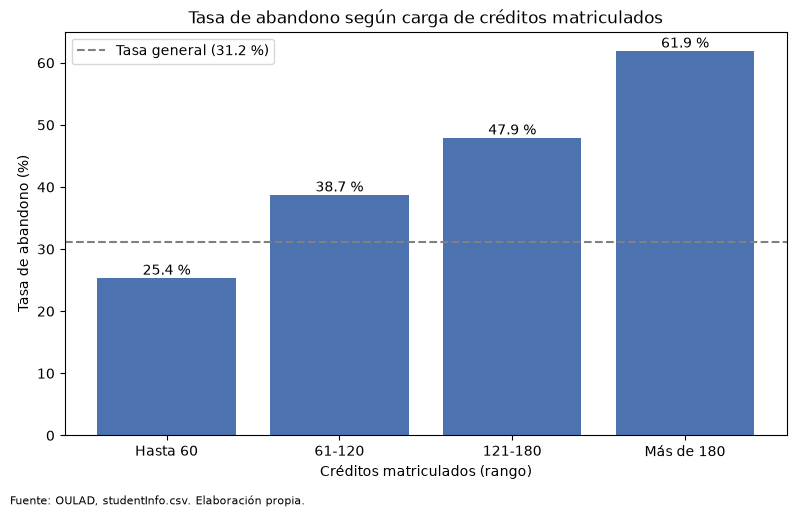

In [5]:
df['rango_creditos'] = pd.cut(
    df['studied_credits'],
    bins=[0, 60, 120, 180, float('inf')],
    labels=['Hasta 60', '61-120', '121-180', 'Más de 180']
)
abandono_creditos = df.groupby('rango_creditos', observed=True)['abandono'].mean() * 100
print(abandono_creditos.round(2))

fig, ax = plt.subplots(figsize=(8, 5))
barras = ax.bar(abandono_creditos.index.astype(str), abandono_creditos.values, color='#4C72B0')
ax.bar_label(barras, fmt='%.1f %%')
ax.axhline(tasa, color='grey', linestyle='--', label=f'Tasa general ({tasa:.1f} %)')
ax.set_title('Tasa de abandono según carga de créditos matriculados')
ax.set_xlabel('Créditos matriculados (rango)')
ax.set_ylabel('Tasa de abandono (%)')
ax.legend()
fig.text(0.01, -0.02, FUENTE, fontsize=8)
plt.tight_layout()
plt.show()

---
## Modelado

### Pregunta 6. ¿Cuál es la variable objetivo, qué clases tiene y qué modelo utilizaron?

**Variable objetivo:** `abandono` (clasificación **binaria**), derivada de `final_result`:

- **1 = Abandono:** `final_result = Withdrawn`.
- **0 = No abandono:** `Pass`, `Fail` o `Distinction`.

**Modelos utilizados:** **ambos** modelos revisados en clase.

- **Regresión Logística** (`02_regresion_logistica.ipynb`): estima la **probabilidad** de
  abandono de cada estudiante y sus coeficientes indican qué variables aumentan o reducen el
  riesgo. Es pertinente porque una probabilidad permite ordenar a los estudiantes por riesgo.
- **Árbol de Decisión** (`03_arbol_decision.ipynb`): clasifica mediante **preguntas sencillas**
  (por ejemplo "¿tiene más de 82 créditos?"). Es pertinente porque sus reglas se pueden explicar
  fácilmente a coordinadores y tutores.

In [6]:
tabla = df.groupby(['final_result', 'abandono']).size().rename('Registros').reset_index()
print(tabla, '\n')
print(df['abandono'].value_counts().rename({0: 'No abandono (0)', 1: 'Abandono (1)'}))

  final_result  abandono  Registros
0  Distinction         0       3024
1         Fail         0       7052
2         Pass         0      12361
3    Withdrawn         1      10156 

abandono
No abandono (0)    22437
Abandono (1)       10156
Name: count, dtype: int64


### Pregunta 7. ¿Qué proporción usaron para entrenamiento y prueba, y cómo hicieron la separación?

En los modelos finales de **ambos** notebooks se usó la misma partición:

| Conjunto | Proporción | Registros | Uso |
|---|---:|---:|---|
| Entrenamiento | 70 % | 22.815 | Ajustar el modelo (y buscar hiperparámetros del árbol) |
| Validación | 15 % | 4.889 | Elegir el punto de corte (umbral) |
| Prueba | 15 % | 4.889 | Evaluación final, **una sola vez** |

**Método:** `train_test_split` en dos pasos (70/30 y luego 50/50 del 30 %), con
`stratify=y` para mantener ~31 % de abandono en los tres conjuntos y semilla
`random_state=777` para que sea reproducible.

**Cómo evitamos la fuga de información:**

- `final_result` (de donde sale el objetivo) e `id_student` **no se usan como predictores**.
- El faltante de `imd_band` se rellena con un valor fijo (`Unknown`), sin calcular nada con los datos.
- La búsqueda de hiperparámetros del árbol (`GridSearchCV`, 5 pliegues) usa **solo entrenamiento**.
- El umbral se elige con **validación** (Youden en el árbol, F1 en la regresión). **Prueba** no
  se usa para ninguna decisión, solo para medir el resultado final.

In [7]:
variables = ['code_module', 'code_presentation', 'gender', 'region', 'highest_education',
             'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability']

X = df[variables].copy()
X['imd_band'] = X['imd_band'].fillna('Unknown')
y = df['abandono']

X = pd.get_dummies(X, columns=X.select_dtypes(exclude='number').columns, drop_first=True, dtype=int)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp)

pd.DataFrame({
    'Conjunto': ['Entrenamiento', 'Validación', 'Prueba'],
    'Registros': [len(X_train), len(X_val), len(X_test)],
    'Proporción (%)': [len(X_train) / len(X) * 100, len(X_val) / len(X) * 100, len(X_test) / len(X) * 100],
    'Abandono (%)': [y_train.mean() * 100, y_val.mean() * 100, y_test.mean() * 100],
}).round(2)

,Conjunto,Registros,Proporción (%),Abandono (%)
0,Entrenamiento,22815,70.0,31.16
1,Validación,4889,15.0,31.15
2,Prueba,4889,15.0,31.17


### Pregunta 8. ¿Cuáles son las variables más importantes y cómo determinaron su importancia?

**Árbol de Decisión:** se usó `feature_importances_`, que mide **cuánto ayuda cada variable a
separar abandono de no abandono** (reducción de impureza de Gini) sumado en todo el árbol.
Las más importantes son:

1. **Créditos matriculados:** ~34 % de la importancia total.
2. **Módulo = CCC:** ~10 %.
3. **Educación previa = Inferior a A Level:** ~9 %.
4. **Módulo = GGG:** ~7 %.

**Regresión Logística** (`02_regresion_logistica.ipynb`): se usaron los **coeficientes**, sus
**odds ratio** y el **p-value** (28 categorías significativas con p < 0,05).

**Interpretación de una variable (`studied_credits`):** en la regresión su odds ratio es
**1,0087**. Por cada crédito adicional, las *odds* de abandono se multiplican por 1,0087
(+0,87 %). Con 60 créditos más, las odds son aproximadamente 1,7 veces mayores, manteniendo
fijas las demás variables. En el módulo **CCC** el odds ratio es **3,93** respecto al módulo de
referencia (AAA).

**Límite:** son **asociaciones predictivas, no causas**. Que una variable sea importante no
significa que cambiarla reduzca el abandono.

studied_credits                         34.33
code_module_CCC                          9.88
highest_education_Lower Than A Level     8.78
code_module_GGG                          7.38
code_presentation_2014J                  4.55
code_module_DDD                          3.89
region_Scotland                          3.06
gender_M                                 2.91
disability_Y                             2.66
imd_band_Unknown                         1.88
dtype: float64


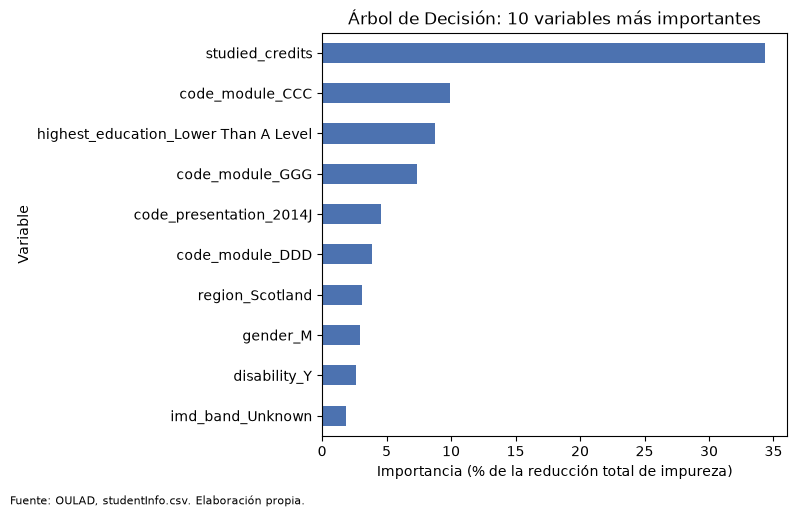

In [8]:
arbol = DecisionTreeClassifier(max_depth=10, min_samples_leaf=20, min_samples_split=2,
                               random_state=RANDOM_STATE)
arbol.fit(X_train, y_train)

importancias = (pd.Series(arbol.feature_importances_ * 100, index=X_train.columns)
                .sort_values(ascending=False).head(10))
print(importancias.round(2))

fig, ax = plt.subplots(figsize=(8, 5))
importancias.sort_values().plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_title('Árbol de Decisión: 10 variables más importantes')
ax.set_xlabel('Importancia (% de la reducción total de impureza)')
ax.set_ylabel('Variable')
fig.text(0.01, -0.02, FUENTE, fontsize=8)
plt.tight_layout()
plt.show()

> Hiperparámetros del árbol: `max_depth=10`, `min_samples_leaf=20`, `min_samples_split=2`.
> Son los que eligió `GridSearchCV` (F1, 5 pliegues, solo con entrenamiento) en
> `03_arbol_decision.ipynb`.

### Pregunta 9. ¿Qué desempeño obtuvo el modelo en el conjunto de prueba?

Resultados en **prueba** (4.889 registros, de los cuales 1.524 son abandonos reales):

| Métrica (clase Abandono) | Árbol de Decisión | Regresión Logística |
|---|---:|---:|
| Umbral (elegido en validación) | 0,32 (Youden) | 0,27 (máx. F1) |
| Exactitud (Accuracy) | **0,631** | 0,564 |
| Precisión | **0,430** | 0,393 |
| Sensibilidad (Recall) | 0,564 | **0,731** |
| F1-score | 0,488 | **0,511** |
| AUC-ROC | 0,644 | **0,673** |

**Matrices de confusión en prueba:**

| | Árbol | Regresión |
|---|---:|---:|
| Abandonos detectados (VP) | 860 | 1.114 |
| Abandonos **no detectados** (FN) | 664 | **410** |
| Falsas alertas (FP) | 1.138 | 1.722 |
| No abandono correcto (VN) | 2.227 | 1.643 |

**Qué error importa más reducir:** los **falsos negativos**, es decir, estudiantes que sí abandonan
pero el modelo no los marca. A ellos no les llega ninguna ayuda. Una falsa alerta solo cuesta
una tutoría de más. Por eso priorizamos la **Sensibilidad**, y en eso la Regresión Logística
es mejor (detecta 73 de cada 100 abandonos).

**Lectura honesta:** la exactitud está por debajo de predecir siempre "No abandono" (0,688),
porque al bajar el umbral para detectar más abandonos se generan más falsas alertas. Ninguno
de los dos modelos alcanza todavía el criterio técnico (Recall ≥ 0,75 y F1 ≥ 0,70).

**Mejora comprobable propuesta:** agregar variables de **actividad temprana** del estudiante
(clics en la plataforma `studentVle` y notas de las primeras evaluaciones `studentAssessment`
de OULAD), reentrenar con la misma partición y semilla, y comparar Recall y F1 en el mismo
conjunto de prueba.

Umbral elegido en validación: 0.3226

Exactitud (Accuracy)                           0.6314
Precisión                                      0.4304
Sensibilidad (Recall)                          0.5643
F1-score                                       0.4884
AUC-ROC                                        0.6439
Exactitud prediciendo siempre 'No abandono'    0.6883


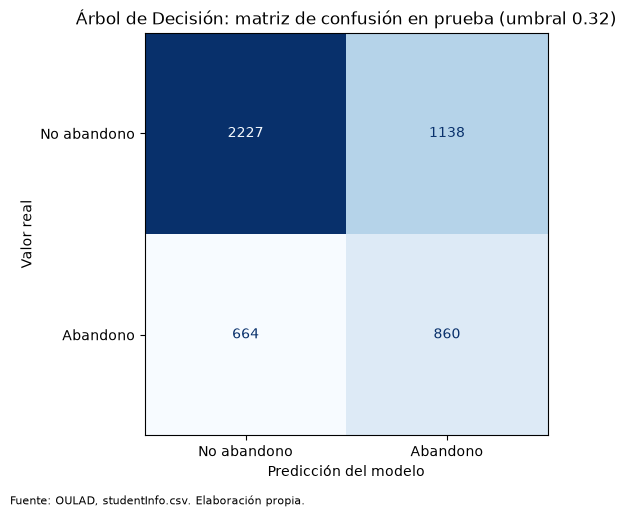

In [9]:
# Punto de corte con Índice de Youden sobre VALIDACIÓN
prob_val = arbol.predict_proba(X_val)[:, 1]
fpr, tpr, umbrales = roc_curve(y_val, prob_val)
umbral = float(umbrales[np.argmax(tpr - fpr)])

# Evaluación final sobre PRUEBA, con el umbral ya fijado
prob_test = arbol.predict_proba(X_test)[:, 1]
pred_test = (prob_test >= umbral).astype(int)

print(f'Umbral elegido en validación: {umbral:.4f}\n')
print(pd.Series({
    'Exactitud (Accuracy)': accuracy_score(y_test, pred_test),
    'Precisión': precision_score(y_test, pred_test),
    'Sensibilidad (Recall)': recall_score(y_test, pred_test),
    'F1-score': f1_score(y_test, pred_test),
    'AUC-ROC': roc_auc_score(y_test, prob_test),
    "Exactitud prediciendo siempre 'No abandono'": 1 - y_test.mean(),
}).round(4).to_string())

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred_test),
                       display_labels=['No abandono', 'Abandono']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Árbol de Decisión: matriz de confusión en prueba (umbral {umbral:.2f})')
ax.set_xlabel('Predicción del modelo')
ax.set_ylabel('Valor real')
fig.text(0.01, -0.02, FUENTE, fontsize=8)
plt.tight_layout()
plt.show()

### Pregunta 10. ¿Qué visualización permite entender cómo toma decisiones el modelo?

La visualización es el **Árbol de Decisión**, que muestra el modelo como una secuencia de
preguntas. Abajo se dibujan sus **dos primeros niveles**.

**Cómo leer cada recuadro:** la primera línea es la pregunta. Si la respuesta es **verdadera**
(`True`) se sigue a la **izquierda**; si es falsa, a la **derecha**. `samples` es cuántos
registros llegan y `value` es la proporción de [no abandono, abandono].

> En las variables dummy (por ejemplo `code_module_GGG <= 0.5`), **verdadero significa que
> el estudiante NO pertenece** a ese módulo.

**Ruta de decisión interpretada:**

1. Al inicio, el **31,2 %** de los registros de entrenamiento son abandono.
2. Primera pregunta: **¿`studied_credits` ≤ 82?**
   - **Sí** (izquierda): el grupo baja a **25,4 %** de abandono.
   - **No** (derecha): el grupo sube a **41,2 %** de abandono.
3. En la rama de **más de 82 créditos**, si además tiene **más de 172 créditos**, el abandono
   llega al **57,2 %**: es el grupo de mayor riesgo en estos dos niveles.

**Qué aporta:** el modelo deja de ser una "caja negra". Cualquier coordinador puede seguir las
preguntas y entender por qué un estudiante queda marcado en riesgo. La carga de créditos es lo
primero que mira el modelo. Es una regla **predictiva, no causal**.

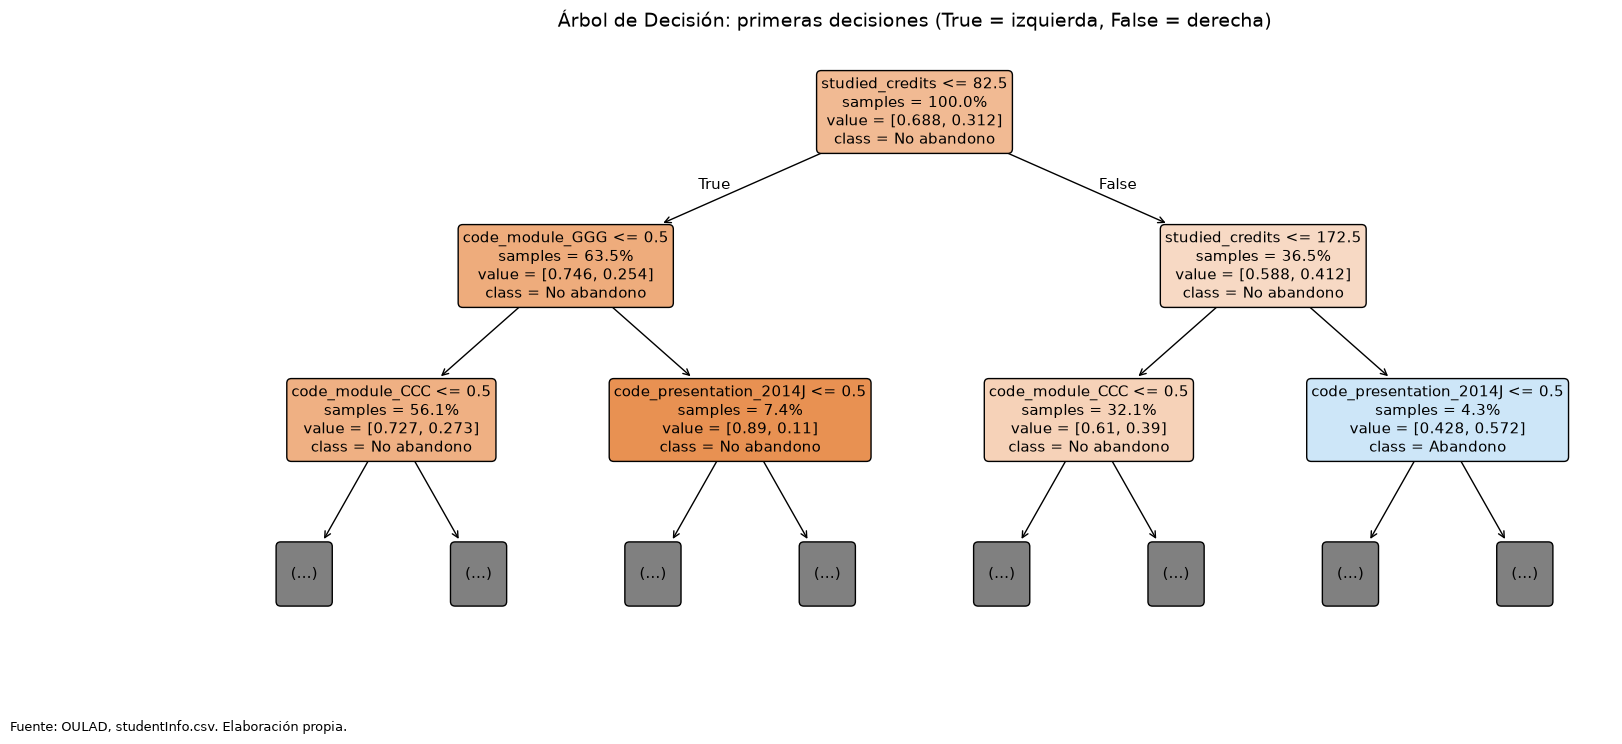

In [10]:
fig, ax = plt.subplots(figsize=(18, 8))
plot_tree(
    arbol,
    max_depth=2,
    feature_names=X_train.columns,
    class_names=['No abandono', 'Abandono'],
    filled=True,
    proportion=True,
    impurity=False,
    rounded=True,
    fontsize=11,
    ax=ax,
)
ax.set_title('Árbol de Decisión: primeras decisiones (True = izquierda, False = derecha)', fontsize=14)
fig.text(0.01, 0.01, FUENTE, fontsize=9)
plt.show()

In [11]:
# Las mismas decisiones en texto, con el significado correcto de cada rama
t = arbol.tree_
cols = X_train.columns

def condicion(nodo, izquierda):
    var, corte = cols[t.feature[nodo]], t.threshold[nodo]
    es_dummy = set(X_train[var].unique()) <= {0, 1}
    if es_dummy:
        return f'{var} = 0 (NO pertenece)' if izquierda else f'{var} = 1 (SÍ pertenece)'
    return f'{var} <= {corte:.0f}' if izquierda else f'{var} > {corte:.0f}'

def recorrer(nodo=0, nivel=0, texto='INICIO'):
    v = t.value[nodo][0]
    print('    ' * nivel + f'{texto} -> abandono: {v[1] / v.sum():.1%}  ({t.n_node_samples[nodo]:,} registros)')
    if nivel < 2 and t.children_left[nodo] != -1:
        recorrer(t.children_left[nodo], nivel + 1, condicion(nodo, True))
        recorrer(t.children_right[nodo], nivel + 1, condicion(nodo, False))

recorrer()

INICIO -> abandono: 31.2%  (22,815 registros)
    studied_credits <= 82 -> abandono: 25.4%  (14,493 registros)
        code_module_GGG = 0 (NO pertenece) -> abandono: 27.3%  (12,808 registros)
        code_module_GGG = 1 (SÍ pertenece) -> abandono: 11.0%  (1,685 registros)
    studied_credits > 82 -> abandono: 41.2%  (8,322 registros)
        studied_credits <= 172 -> abandono: 39.0%  (7,330 registros)
        studied_credits > 172 -> abandono: 57.2%  (992 registros)


---
## Resumen

| Pregunta | Respuesta corta |
|---|---|
| 1 | Abandono del 31,16 %; apoyar la priorización del seguimiento; meta futura 28,04 % |
| 2 | Tasa de abandono = abandonos / total × 100 = **31,16 %** (métrica de negocio) |
| 3 | Fila = inscripción estudiante–módulo–presentación; OULAD; 32.593 × 12; sin filtros |
| 4 | `imd_band` con 1.111 faltantes → `Unknown`; 0 duplicados; 350 atípicos conservados |
| 5 | El abandono sube con los créditos: 25,35 % (≤ 60) → 61,92 % (> 180) |
| 6 | `abandono` (1 = Withdrawn, 0 = resto); Regresión Logística y Árbol de Decisión |
| 7 | 70 / 15 / 15, estratificado, semilla 777; prueba solo para la evaluación final |
| 8 | Créditos (34 %), Módulo CCC, educación previa, Módulo GGG |
| 9 | Árbol: Acc 0,631, Recall 0,564, F1 0,488; Regresión: Recall 0,731, F1 0,511 |
| 10 | Árbol de decisión: primera pregunta "¿créditos ≤ 82?" (25,4 % vs 41,2 % de abandono) |